# Helmholtz physical adjoint reciprocity test

Goal: check the linear case of Theorem 8.1 (Section 8.1), which says a steady-state Helmholtz (scattering) system gives the correct gradient from one run on the same hardware when it is reciprocal, $A^T=A$. The notebook solves the forward problem, then computes the adjoint two ways: the exact way ($A^Tc=P\psi_e$) and the hardware way ($Ac=P\psi_e$). Taylor tests on a reciprocal but non-Hermitian matrix and on a nonreciprocal one show that the hardware gradient is correct only in the reciprocal case, while the exact one is correct in both.

The forward steady-state problem is

$$
A(p_A)e=b(p_b).
$$

For the real-valued loss

$$
\chi(e)=\frac12\|Pe-y_*\|^2,
$$

the raw Wirtinger adjoint satisfies

$$
\overline{A(p_A)^T}a=P\psi_{\bar e}.
$$

Complex conjugating gives the physically useful `c`-adjoint equation

$$
A(p_A)^T c=P\psi_e,
\qquad c=\bar a.
$$

The exact `c`-adjoint therefore requires the transposed scattering operator. A same-hardware physical run can instead solve only

$$
A(p_A)c_{phys}=P\psi_e.
$$

These coincide precisely when the system is reciprocal,

$$
A(p_A)^T=A(p_A).
$$

The gradient overlaps can be evaluated directly from the `c`-field without explicitly forming `a`:

$$
\frac{d\chi}{dp_A}
=-2\operatorname{Re}\left[c^T A_{p_A}e\right],
\qquad
\frac{d\chi}{dp_b}
=2\operatorname{Re}\left[c^T b_{p_b}\right].
$$

Below we compare a complex-symmetric, non-Hermitian reciprocal matrix with a nonreciprocal matrix. The exact digital `c`-adjoint, which solves $A^Tc=P\psi_e$, should pass the Taylor test in both cases. The same-hardware physical adjoint should pass only in the reciprocal case.


### Setup
Imports, the $2\times2$ measurement projector $P$ (here the identity, so both modes are observed), the target field $y_*$, and the labels for the six trainable parameters.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

complex_dtype = np.complex128
P = np.eye(2, dtype=complex_dtype)

target = np.array([0.2 + 0.1j, -0.3 + 0.4j], dtype=complex_dtype)
parameter_names = ["A00", "A01", "A10", "A11", "b0", "b1"]

np.set_printoptions(precision=6, suppress=False)


### Model, adjoint solvers, and gradient formula
$A(p_A)$ carries $+i$ and $-i$ on its diagonal, so it is non-Hermitian for every parameter value. Whether it is reciprocal depends only on $A_{01}$ versus $A_{10}$.

The cell defines three adjoint solves:
- `exact_c_adjoint` solves $A^Tc=P\psi_e$. This is the correct $c$-field.
- `physical_c_adjoint` solves $Ac=P\psi_e$. This is all the same hardware can do, since it cannot transpose itself.
- `raw_digital_adjoint` solves the unconjugated Wirtinger equation $A^\dagger a=P\psi_{\bar e}$, as a check that $c=\bar a$.

`gradients_from_c` evaluates the two overlap formulas from the introduction. `taylor_errors` returns the first-order Taylor remainder along a fixed direction.

In [18]:
def A(pA):
    pA = np.asarray(pA, dtype=float)
    return np.array(
        [
            [pA[0] + 1j, pA[1]],
            [pA[2], pA[3] - 1j],
        ],
        dtype=complex_dtype,
    )


def b(pB):
    pB = np.asarray(pB, dtype=float)
    return np.array([pB[0], pB[1]], dtype=complex_dtype)


def dA_dp(index):
    mats = [
        np.array([[1, 0], [0, 0]], dtype=complex_dtype),
        np.array([[0, 1], [0, 0]], dtype=complex_dtype),
        np.array([[0, 0], [1, 0]], dtype=complex_dtype),
        np.array([[0, 0], [0, 1]], dtype=complex_dtype),
    ]
    return mats[index]


def db_dp(index):
    vecs = [
        np.array([1, 0], dtype=complex_dtype),
        np.array([0, 1], dtype=complex_dtype),
    ]
    return vecs[index]


def loss(e):
    residual = P @ e - target
    return 0.5 * np.vdot(residual, residual).real


def psi_ebar(e):
    return P.conj().T @ (0.5 * (P @ e - target))


def psi_e(e):
    return P.T @ np.conjugate(0.5 * (P @ e - target))


def forward_problem(pA, pB):
    return np.linalg.solve(A(pA), b(pB))


def exact_c_adjoint(pA, pB):
    e = forward_problem(pA, pB)
    return np.linalg.solve(A(pA).T, psi_e(e))


def physical_c_adjoint(pA, pB):
    e = forward_problem(pA, pB)
    return np.linalg.solve(A(pA), psi_e(e))


def raw_digital_adjoint(pA, pB):
    e = forward_problem(pA, pB)
    return np.linalg.solve(A(pA).conj().T, psi_ebar(e))


def gradients_from_c(e, c):
    grad_pA = np.array([-2.0 * np.real(c @ (dA_dp(i) @ e)) for i in range(4)])
    grad_pB = np.array([2.0 * np.real(c @ db_dp(i)) for i in range(2)])
    return grad_pA, grad_pB


def cost_from_vector(p):
    return loss(forward_problem(p[:4], p[4:]))


def taylor_errors(p, gradients, h_values, direction):
    chi0 = cost_from_vector(p)
    p_scale = np.mean(np.abs(p))
    errors = {}
    for label, gradient in gradients.items():
        errors[label] = np.array([
            abs(cost_from_vector(p + h * p_scale * direction) - chi0 - gradient @ (h * p_scale * direction))
            for h in h_values
        ])
    return errors


def solve_case(label, pA, pB):
    e = forward_problem(pA, pB)
    c_exact = exact_c_adjoint(pA, pB)
    c_physical = physical_c_adjoint(pA, pB)
    a_raw = raw_digital_adjoint(pA, pB)
    grad_exact = np.r_[*gradients_from_c(e, c_exact)]
    grad_physical = np.r_[*gradients_from_c(e, c_physical)]
    return {
        "label": label,
        "p": np.r_[pA, pB],
        "e": e,
        "c_exact": c_exact,
        "c_physical": c_physical,
        "a_raw": a_raw,
        "grad_exact": grad_exact,
        "grad_physical": grad_physical,
    }


### Reciprocal vs. nonreciprocal case
Both cases use the same source; they differ only in $A_{10}$ ($0.3$ vs. $-0.4$). The printout shows why transpose symmetry, not Hermiticity, is the condition that matters:
- Both matrices are non-Hermitian.
- The physical $c$-field equals the exact one only when $\|A-A^T\|=0$.

The check $\|\bar a_{\rm raw}-c_{\rm exact}\|$ just confirms the conjugation convention.

In [19]:
pB = np.array([1.0, -0.7], dtype=float)

cases = [
    solve_case("reciprocal", np.array([2.0, 0.3, 0.3, 1.5], dtype=float), pB),
    solve_case("nonreciprocal", np.array([2.0, 0.3, -0.4, 1.5], dtype=float), pB),
]

for result in cases:
    pA = result["p"][:4]
    A_defect = np.linalg.norm(A(pA) - A(pA).T)
    hermitian_defect = np.linalg.norm(A(pA) - A(pA).conj().T)
    c_error = np.linalg.norm(result["c_physical"] - result["c_exact"]) / np.linalg.norm(result["c_exact"])
    grad_error = np.linalg.norm(result["grad_physical"] - result["grad_exact"]) / np.linalg.norm(result["grad_exact"])
    raw_c_error = np.linalg.norm(np.conjugate(result["a_raw"]) - result["c_exact"])

    print(f"{result['label']} case")
    print(f"  ||A-A.T||: {A_defect:.3e}")
    print(f"  ||A-A^dagger||: {hermitian_defect:.3e}")
    print(f"  ||conj(a_raw)-c_exact||: {raw_c_error:.3e}")
    print(f"  relative physical/exact c-field error: {c_error:.3e}")
    print(f"  relative physical/exact gradient error: {grad_error:.3e}")
    print()


reciprocal case
  ||A-A.T||: 0.000e+00
  ||A-A^dagger||: 2.828e+00
  ||conj(a_raw)-c_exact||: 0.000e+00
  relative physical/exact c-field error: 0.000e+00
  relative physical/exact gradient error: 0.000e+00

nonreciprocal case
  ||A-A.T||: 9.899e-01
  ||A-A^dagger||: 2.997e+00
  ||conj(a_raw)-c_exact||: 0.000e+00
  relative physical/exact c-field error: 3.262e-01
  relative physical/exact gradient error: 2.029e-01



### Taylor test of the physical gradient
For a correct gradient $g$, the remainder $|\chi(p+hv)-\chi(p)-g^Thv|$ falls as $h^2$. For a wrong gradient it falls only as $h$. The direction $v$ is random and normalized, and steps are scaled by $\mathrm{mean}|p|$. The flat region at small $h$ is floating-point roundoff.

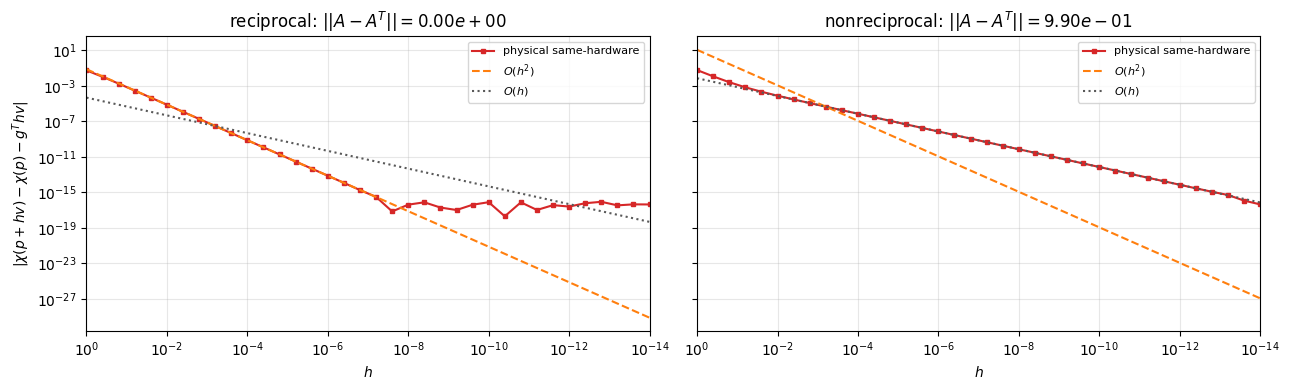

In [ ]:
rng = np.random.default_rng(3)
direction = rng.normal(size=len(parameter_names))
direction = direction / np.linalg.norm(direction)
h_values = np.logspace(0, -14, 36)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"physical same-hardware": result["grad_physical"]},
        h_values,
        direction,
    )
    anchor = 8
    ref2 = errors["physical same-hardware"][anchor] * (h_values / h_values[anchor]) ** 2
    ref1 = errors["physical same-hardware"][anchor] * (h_values / h_values[anchor])

    ax.loglog(h_values, errors["physical same-hardware"], "s-", ms=3, color="tab:red", label="physical same hardware")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, ref1, ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: $||A-A^T||={np.linalg.norm(A(result['p'][:4])-A(result['p'][:4]).T):.2e}$")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()


### Control: Taylor test of the exact $c$-adjoint
This repeats the test with the transposed digital solve. It passes in both cases, so the forward solver and overlap formulas are correct. The failure above therefore comes only from the missing transpose.

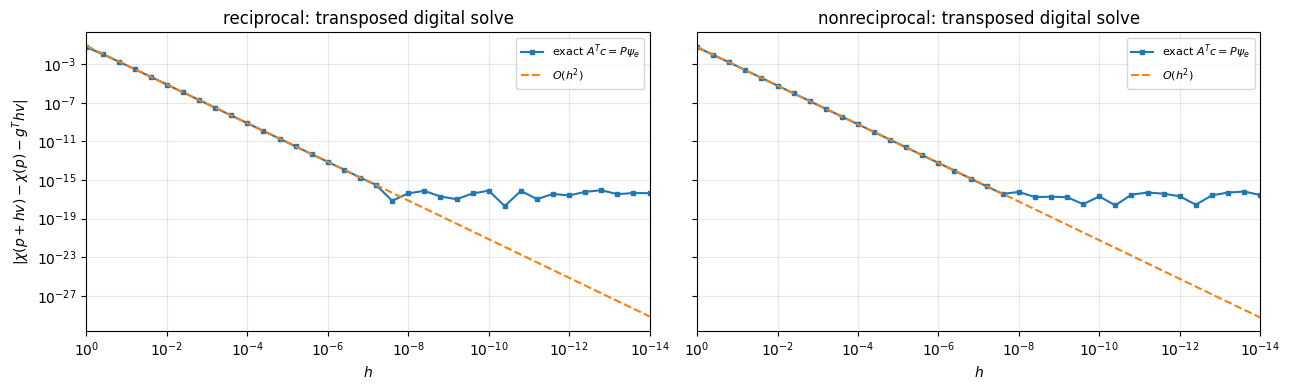

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"exact c-adjoint": result["grad_exact"]},
        h_values,
        direction,
    )
    anchor = 8
    ref2 = errors["exact c-adjoint"][anchor] * (h_values / h_values[anchor]) ** 2

    ax.loglog(h_values, errors["exact c-adjoint"], "s-", ms=3, color="tab:blue", label=r"exact $A^T c=P\psi_e$")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: transposed digital solve")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()
